<a href="https://colab.research.google.com/github/tougheye/CA_public_Health_Facility/blob/main/UPTE_State_Senate_Mapping.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

ca_senate_shape_df = gpd.read_file("/content/CA_State_Senate_Districts_and_Membership_2025-2030.zip")
ca_senate_shape_df.head()

,OBJECTID,F2020_POP,F2020_HU,CRC_Pop,last_name,first_name,district_w,district,phone,party,GlobalID,Shape__Are,Shape__Len,geometry
0,1,1031541,337824,1036292,Gonzalez,Lena,https://senate.ca.gov/sd33,33,916-651-4033,Democrat,9fd8ca3c-5870-444d-9f20-9d357aa917e4,2.542232e+09,4.504620e+05,"MULTIPOLYGON (((-13163631.658 3942073.816, -13..."
1,2,1036642,329615,1033749,Valladares,Suzette Martinez,https://senate.ca.gov/sd23,23,916-651-4023,Republican,b92a26b6-4341-46ec-8aaa-12b527e1cd56,9.912311e+09,6.542898e+05,"POLYGON ((-13073845.803 4073142.205, -13073857..."
2,3,991163,363076,992658,Grayson,Tim,https://senate.ca.gov/sd09,9,916-651-4009,Democrat,9aa44834-cc41-4fbb-8f92-35672a95b770,2.598388e+09,3.459970e+05,"POLYGON ((-13595144.08 4541330.119, -13594945...."
3,4,1033627,415466,1036034,Weber,Akilah,https://senate.ca.gov/sd39,39,916-651-4039,Democrat,451afa53-0d84-41e2-bf22-b378a690c950,9.045994e+08,2.358417e+05,"POLYGON ((-13046658.781 3844811.985, -13046705..."
4,5,1036270,450105,1032056,Alvarado-Gil,Marie,https://senate.ca.gov/sd04,4,916-651-4004,Republican,34cc587f-da7d-440e-84f9-d98e4aac331d,1.047354e+11,2.581875e+06,"POLYGON ((-12965620.218 4362243.045, -12962624..."


In [ ]:
ca_senate_shape_df.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 14 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   OBJECTID    40 non-null     int32   
 1   F2020_POP   40 non-null     int32   
 2   F2020_HU    40 non-null     int32   
 3   CRC_Pop     40 non-null     int32   
 4   last_name   40 non-null     object  
 5   first_name  40 non-null     object  
 6   district_w  40 non-null     object  
 7   district    40 non-null     int32   
 8   phone       40 non-null     object  
 9   party       40 non-null     object  
 10  GlobalID    40 non-null     object  
 11  Shape__Are  40 non-null     float64 
 12  Shape__Len  40 non-null     float64 
 13  geometry    40 non-null     geometry
dtypes: float64(2), geometry(1), int32(5), object(6)
memory usage: 3.7+ KB


In [ ]:
upte_senate_df = pd.read_csv("/content/UPTE_CA_Senate_Summary.csv")
upte_senate_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Senate District  40 non-null     int64
 1   UPTE Headcount   40 non-null     int64
dtypes: int64(2)
memory usage: 772.0 bytes


In [ ]:
ca_senate_shape_df = ca_senate_shape_df.merge(upte_senate_df, left_on="district", right_on="Senate District")

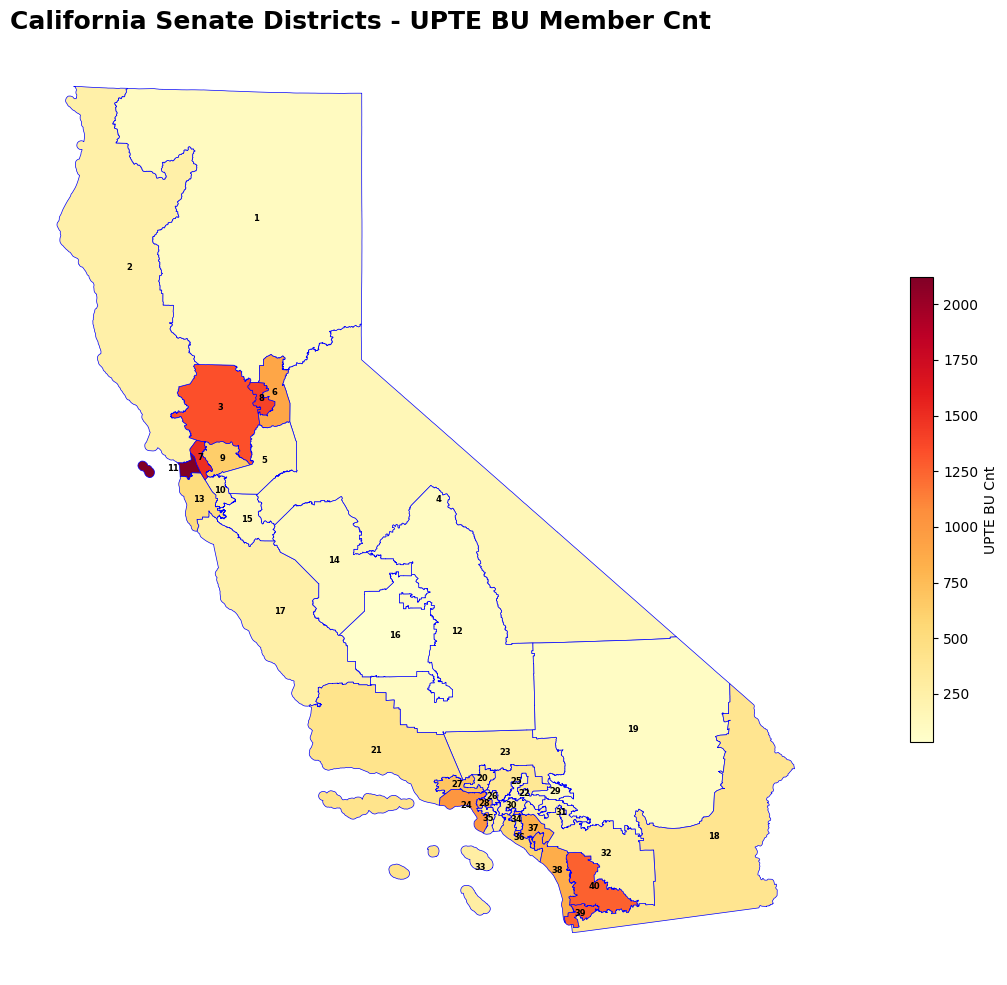

In [ ]:
ca_senate_shape_df = ca_senate_shape_df.to_crs("EPSG:3310")

# create a California specific figure
fig_ca, ax_ca = plt.subplots(figsize=(16, 10))

# setup the color scale
col = 'UPTE Headcount'
vmin = ca_senate_shape_df[col].min()
vmax = ca_senate_shape_df[col].max()
cmap = 'YlOrRd'


# ── Plot California members ──────────────────────────────────────────────────────────
ca_senate_shape_df.plot(ax=ax_ca, column=col, cmap=cmap, vmin=vmin, vmax=vmax,
              edgecolor='blue', linewidth=0.5, legend=True,
           legend_kwds={'label': 'UPTE BU Cnt', 'shrink': 0.5})

# Labels for CA — centroid-based
for _, row in ca_senate_shape_df.iterrows():
    centroid = row.geometry.centroid
    ax_ca.annotate(
        text=row['district'],
        xy=(centroid.x, centroid.y),
        ha='center', va='center',
        fontsize=6, color='black',
        fontweight='bold',
        clip_on=True
    )

ax_ca.set_axis_off()

plt.suptitle('California Senate Districts - UPTE BU Member Cnt',
             fontsize=18, fontweight='bold')
plt.tight_layout()
plt.savefig('upte_ca_map.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# create regional distinctions - 2025 districts - https://sdmg.senate.ca.gov/committeehome/2025-congressional-districts
regional_dict = {"Northern and Sierra": [1, 2, 4],
                 "SF Bay and Greater Sacramento": [3, 6, 7, 8, 9, 10, 11, 13],
                 "Central Valley and High Desert": [5, 15, 14, 16, 12, 19, 23],
                 "Central Coast": [17, 21],
                 "SoCal - Greater LA, OC, IE": [20, 22, 24, 25, 26, 27, 28, 29, 30, 31, 34, 35, 36, 37 ],
                 "SoCal - Greater SD": [ 32, 33, 38, 39, 40 , 18]}

In [ ]:
import pandas as pd
ca_senate_reg_df = pd.Series(regional_dict).explode().reset_index()
ca_senate_reg_df.columns = [ 'Region' , 'Senate District']
ca_senate_reg_df.head()

,Region,Senate District
0,Northern and Sierra,1
1,Northern and Sierra,2
2,Northern and Sierra,4
3,SF Bay and Greater Sacramento,3
4,SF Bay and Greater Sacramento,6


In [ ]:
ca_senate_regional_breakdown = ca_senate_shape_df.merge(ca_senate_reg_df, on='Senate District')
#

In [ ]:
region_list = ca_senate_regional_breakdown['Region'].unique()


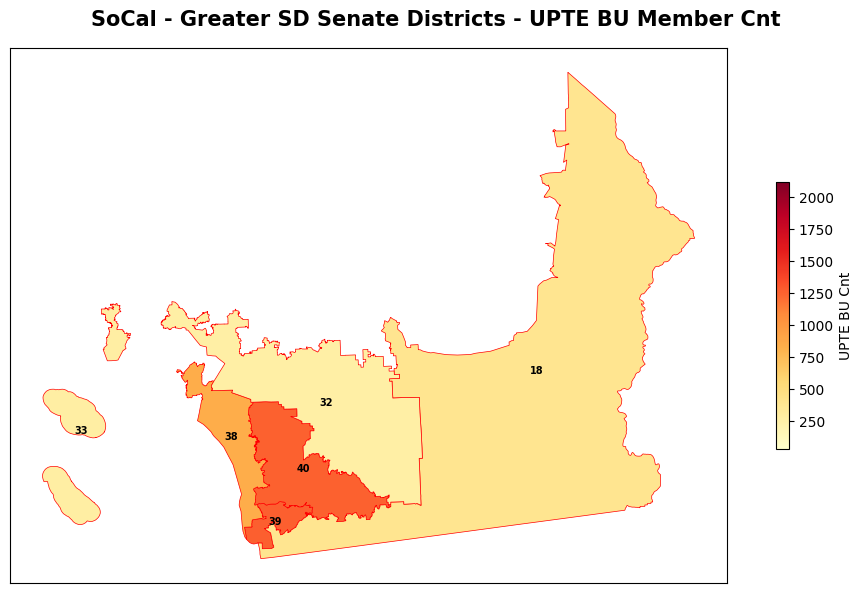

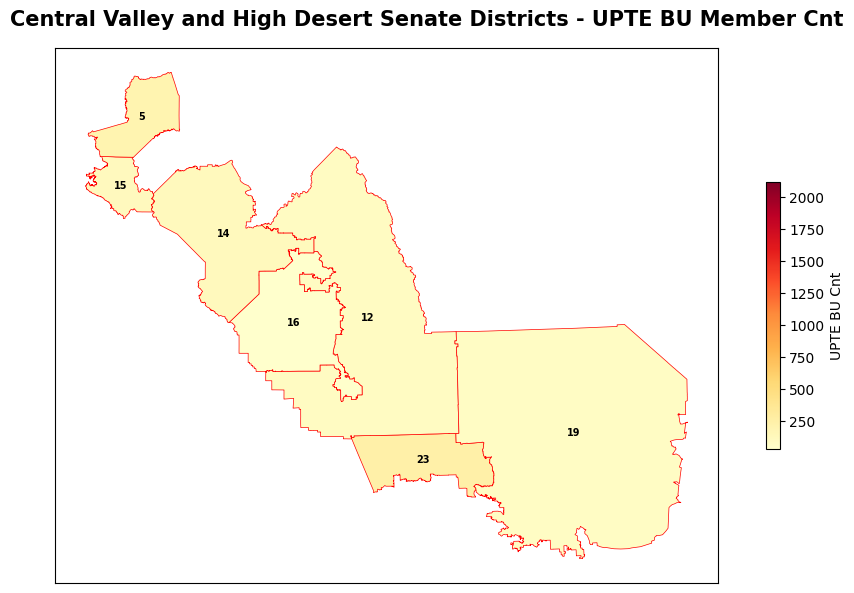

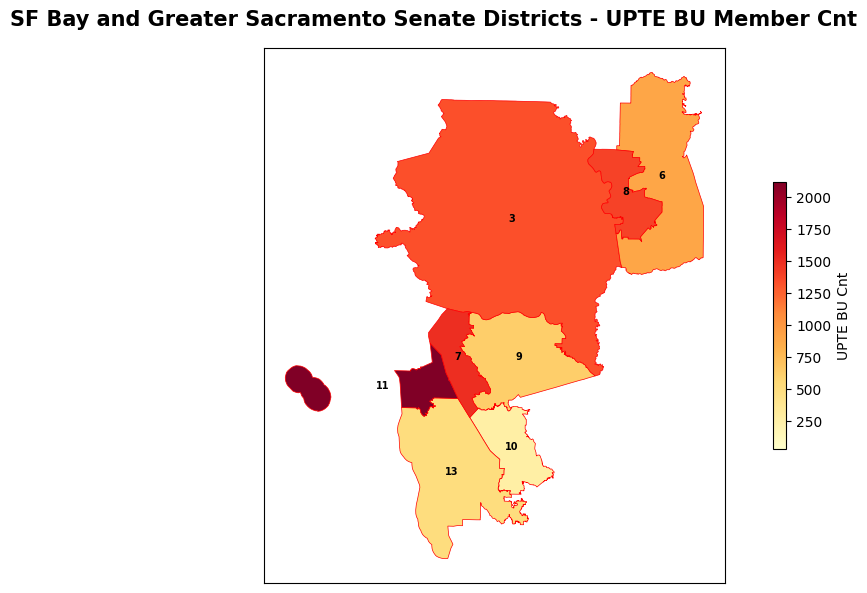

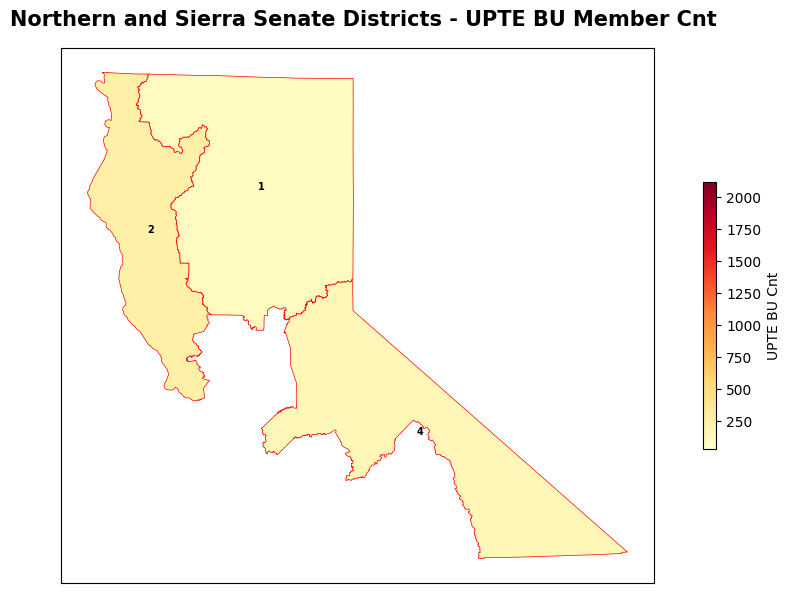

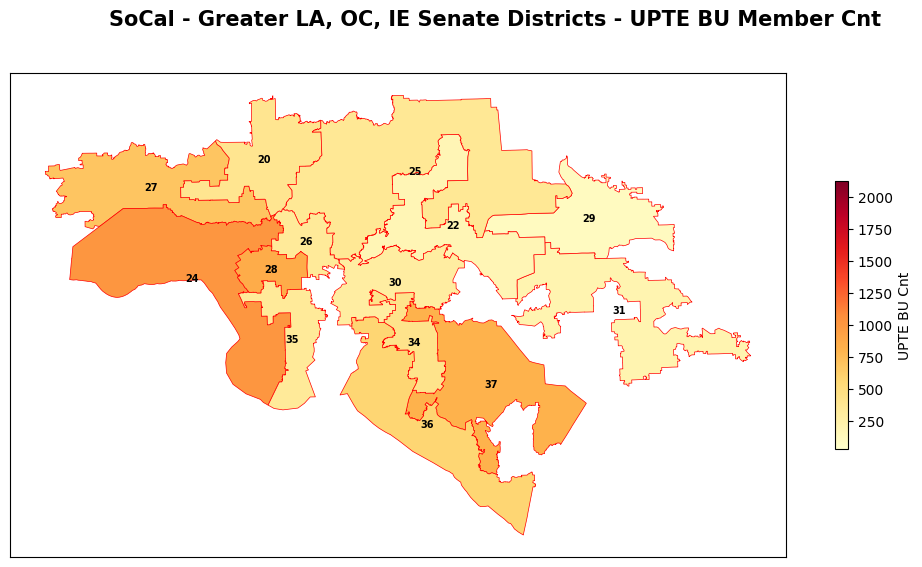

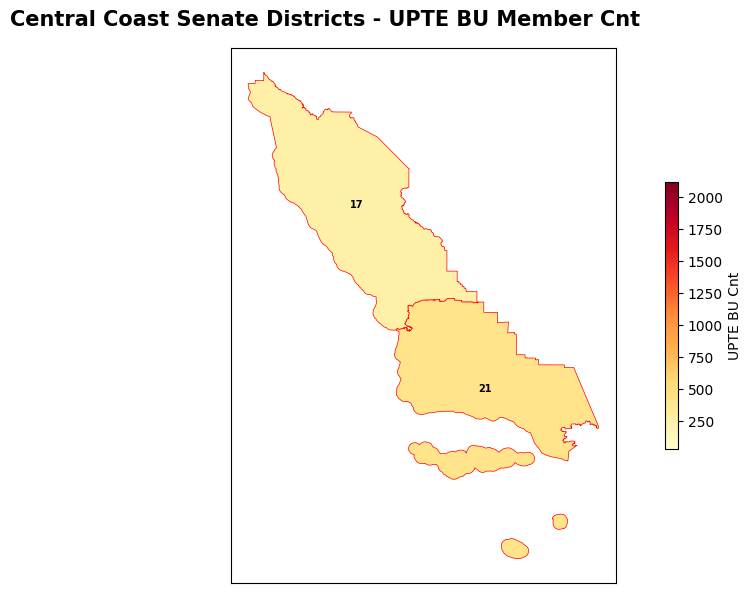

In [ ]:
for region in region_list:
  region_df = ca_senate_regional_breakdown[ca_senate_regional_breakdown['Region'] == region]

  # reproject to regional Albers
  region_df = region_df.to_crs("EPSG:3310")

  # create a region specific figure
  fig_region, ax_region = plt.subplots(figsize=(10, 6))

  # setup the color scale
  col = 'UPTE Headcount'
  vmin = ca_senate_regional_breakdown[col].min()
  vmax = ca_senate_regional_breakdown[col].max()
  cmap = 'YlOrRd'


  # ── Plot region's members ──────────────────────────────────────────────────────────
  region_df.plot(ax=ax_region, column=col, cmap=cmap, vmin=vmin, vmax=vmax,
                edgecolor='red', linewidth=0.5, legend=True,
            legend_kwds={'label': 'UPTE BU Cnt', 'shrink': 0.5})

  # Labels for regions — centroid-based
  for _, row in region_df.iterrows():
      centroid = row.geometry.centroid
      ax_region.annotate(
          text=row['district'],
          xy=(centroid.x, centroid.y),
          ha='center', va='center',
          fontsize=7, color='black',
          fontweight='bold',
          clip_on=True
      )

  ax_region.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)

  plt.suptitle(f'{region} Senate Districts - UPTE BU Member Cnt',
              fontsize=15, fontweight='bold')
  plt.tight_layout()
  plt.savefig(f'{region}_upte_ca_map.png', dpi=150, bbox_inches='tight')
  plt.show()

# print("Done printing all inset maps")